To install it, in the folder run pip install .

# Helper Submodule

In [1]:
import pyfluor.helper as helper
from pyfluor.fluorescence import FluorescenceModel
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt

#### Line lists availables

In [2]:
helper.print_available_linelist_inventory()

Default available for fluorescence:
  - CN 12C14N
  - CN 12C15N
  - CN 13C14N
Comment: for the fluorescence modeling you could also provide your own line list

Available for line plotting:
  - [mol] CN 12C14N
  - [mol] CN 12C15N
  - [mol] CN 13C14N
  - [mol] NEOWISE (C2, C3, NH, CH)
  - [atom] Al
  - [atom] Ar
  - [atom] As
  - [atom] B
  - [atom] Be
  - [atom] Br
  - [atom] C
  - [atom] Ca
  - [atom] Cl
  - [atom] Co
  - [atom] Cr
  - [atom] Cu
  - [atom] F
  - [atom] Fe
  - [atom] Ga
  - [atom] Ge
  - [atom] H
  - [atom] He
  - [atom] K
  - [atom] Kr
  - [atom] Li
  - [atom] Mg
  - [atom] Mn
  - [atom] N
  - [atom] Na
  - [atom] Ne
  - [atom] Ni
  - [atom] O
  - [atom] P
  - [atom] Rb
  - [atom] S
  - [atom] Sc
  - [atom] Se
  - [atom] Si
  - [atom] Sr
  - [atom] Ti
  - [atom] V
  - [atom] Y
  - [atom] zinc_lines_air


CN lines from: Brooke et. al. 2014 and Sneden et. al. 2014
Neowise lines from: Cambianica et. al. 2021
Atomic lines from: NIST Atomic Spectra Database (Kramida et. al. 2020), notice that this lists are not the complete NIST list, just and extract from their tables.

#### Plot different linelists availables

In [3]:
lines_cn_12 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_12 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_13 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="13C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_15 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C15N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_neowise_C2 = helper.get_linelist_wavelengths_vacuum(
    species='C2',
    n_lines=100)
lines_neowise_NH2 = helper.get_linelist_wavelengths_vacuum(
    species='NH2',
    n_lines=100)
lines_neowise_C3 = helper.get_linelist_wavelengths_vacuum(
    species='C3',
    n_lines=100)
lines_neowise_CH = helper.get_linelist_wavelengths_vacuum(
    species='CH',
    n_lines=100)

lines_atomic_iron = helper.get_linelist_wavelengths_vacuum(
    species='Fe',
    n_lines=100)
lines_atomic_nickel = helper.get_linelist_wavelengths_vacuum(
    species='Ni',
    n_lines=100)
lines_atomic_cobalt = helper.get_linelist_wavelengths_vacuum(
    species='Co',
    n_lines=100)

CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).


# Lets upload an spectrum
if the table does not have units enter none in units_row
You can open your data as you prefer

In [3]:
night = '20250924'
fibre = 'A'

spectra = helper.load_spectrum(dir_path='Output_spectras', night=night, fibre=fibre, header_row=1, units_row=0, data_start=3)

spectra.pprint()

       WAVE              FLUX_STACK       ...     WAVENUMBER    
     Angstrom      erg / (Angstrom s cm2) ...       1 / cm      
------------------ ---------------------- ... ------------------
3772.3021197818316                    nan ...  26509.01142716094
  3772.30841109057                    nan ...   26508.9672164663
   3772.3147024098                    nan ... 26508.923005845405
3772.3209937395227                    nan ... 26508.878795298235
 3772.327285079737                    nan ... 26508.834584824806
3772.3335764304447                    nan ... 26508.790374425105
3772.3398677916457                    nan ... 26508.746164099128
3772.3461591633372                    nan ...   26508.7019538469
 3772.352450545522                    nan ... 26508.657743668395
               ...                    ... ...                ...
 7900.474405631213                    nan ... 12657.467750129423
7900.4875817563925                    nan ... 12657.446640498174
7900.5007579035455       

#### lets plot some lines and the spec

In [4]:
%matplotlib widget
from matplotlib import pyplot as plt

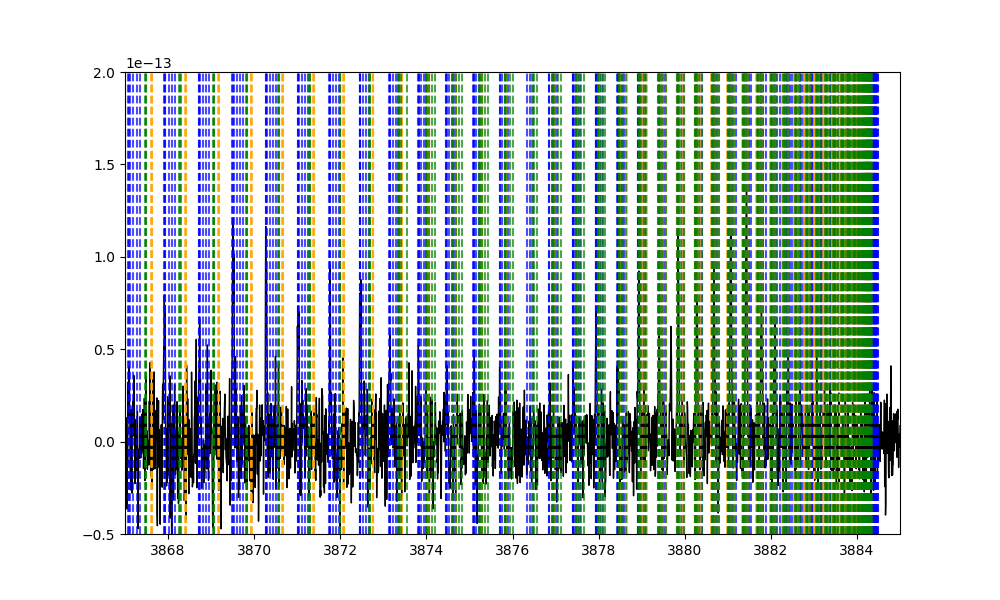

In [6]:

plt.figure(figsize=(10, 6))
plt.plot(spectra['WAVE'], spectra['FLUX_STACK'], label='Spectrum', color='black', lw=1)
for i in lines_cn_12:
    plt.axvline(i, color='blue', linestyle='--', alpha=0.7, label='CN 12C14N' if i == lines_cn_12[0] else "")
for i in lines_cn_13:
    plt.axvline(i, color='orange', linestyle='--', alpha=0.7, label='CN 13C14N' if i == lines_cn_13[0] else "")
for i in lines_cn_15:
    plt.axvline(i, color='green', linestyle='--', alpha=0.7, label='CN 12C15N' if i == lines_cn_15[0] else "")
# for i in lines_atomic_iron:
#     plt.axvline(i, color='red', linestyle=':', alpha=0.7, label='Fe I' if i == lines_atomic_iron[0] else "")
plt.xlim(3867, 3885)
plt.ylim(-5e-14, 2e-13)
plt.show()

#### now lets get the mean values for that nigth the most important in this case is r_au as is going to be used for the incident solar flux calculation at the comet position you can replace this by having r and rdot values in your own way

load_ephemeris_summary allows you to create a dict for different with the mean values for the comet and get_ephemeris_for_nights allows you to filter one night dict from all the nights

In [5]:
from pathlib import Path
path = Path('Ephemeris/ephemeris_means_by_observation.csv')
#you could use the key_column kwarg to set another column as key default is 'date_obs', if is not there schange it as neede
ephemeris_all = helper.load_ephemeris_summary(path)
ephemeris_all
mean_values = helper.get_ephemeris_for_night(ephemeris_all, night)

mean_values

{'date_obs': 20250924,
 'n_exposures': 3,
 'ephemeris_file': 'Ephemeris/horizons_results_20250924.txt',
 'mean_jd_ut': 2460943.4863425926,
 'mean_dra_cosdec_arcsec_per_hr': -73.40633333333334,
 'mean_ddec_arcsec_per_hr': 18.190626666666663,
 'mean_t_mag': 15.507666666666665,
 'mean_r_au': 1.8492717459746668,
 'mean_rdot_km_s': -42.52747686666666,
 'mean_delta_au': 2.5189498192818296,
 'mean_deldot_km_s': -4.3657516,
 'mean_ra_deg': 219.31738194861111,
 'mean_dec_deg': -11.631675350000002,
 'mean_MJD': 60942.986342592594}

#### Remember the previous cell is optional, if you want to have r, delta, rdot, deltadot, or any other usefull value you can create your own dict, list, etc... with that values

# Now lets get the values of the solar irradiance that night

## 2 Options here:
 1) Load pre-calculated solar fluxes at the comet distance (I previously fitted a little delta lambda up the solar velocity to match the solar lines in the comet spectrum, so I used that solar irradiance here)
 2) Load the solar flux at 1 au (Kurucz)and shift it according to the comet from your machine or using the one stored in the package, for this is important to be concistent with the units, the default kurucz in the module is in u.AA and u.erg / (u.s * u.cm**2 * u.AA)


##### Option 1

In [6]:
# For this option there are kwargs to load different column names, name formats, etc...

solar = helper.load_pumping_file(night=night, directory='Pumping_files', scale_by_r_au=mean_values['mean_r_au'])

##### Option 2

In [6]:
import pandas as pd
import numpy as np

from astropy import constants as c
from astropy import units as u
# Option 2a: load from a local file shift the wavelength accordingly by the rdot andscale with the distance:
# solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/rdot**2})

#Option 2b: load from the preloaded file in the package

# Another option is using the preloaded kurucz in the helper
kurucz = helper.open_kurucz_irradiance()
wave = kurucz['WAVE']
flux = kurucz['FLUX']

beta   =  mean_values['mean_rdot_km_s']/ c.c.to(u.km / u.s).value
factor = np.sqrt((1.0 + beta) / (1.0 - beta))

wave_shifted = wave * factor
solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/mean_values['mean_r_au']**2})

NameError: name 'helper' is not defined

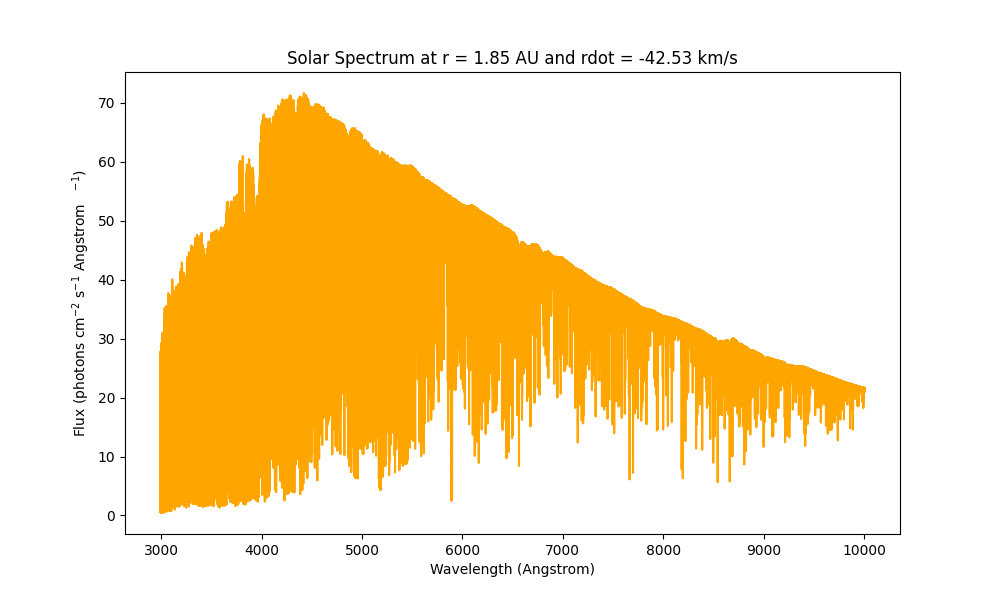

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(solar['WAVE'], solar['FLUX'], label='Solar Spectrum', color='orange')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (photons cm$^{-2}$ s$^{-1}$ Angstrom   $^{-1}$)')
plt.title('Solar Spectrum at r = {:.2f} AU and rdot = {:.2f} km/s'.format(mean_values['mean_r_au'], mean_values['mean_rdot_km_s']))
plt.show()

This are the most important functions iin this submodule, there are another ones, but mainly to find paths, list files, etc...

### The modeling submodule has a lot of good functions I recomend to check it out, however almost all of them are used with the fluorescence submodule so we are going to focus there.

# Now lets create a model using the FluorescenceModel class

In [11]:
from pyfluor.fluorescence import FluorescenceModel

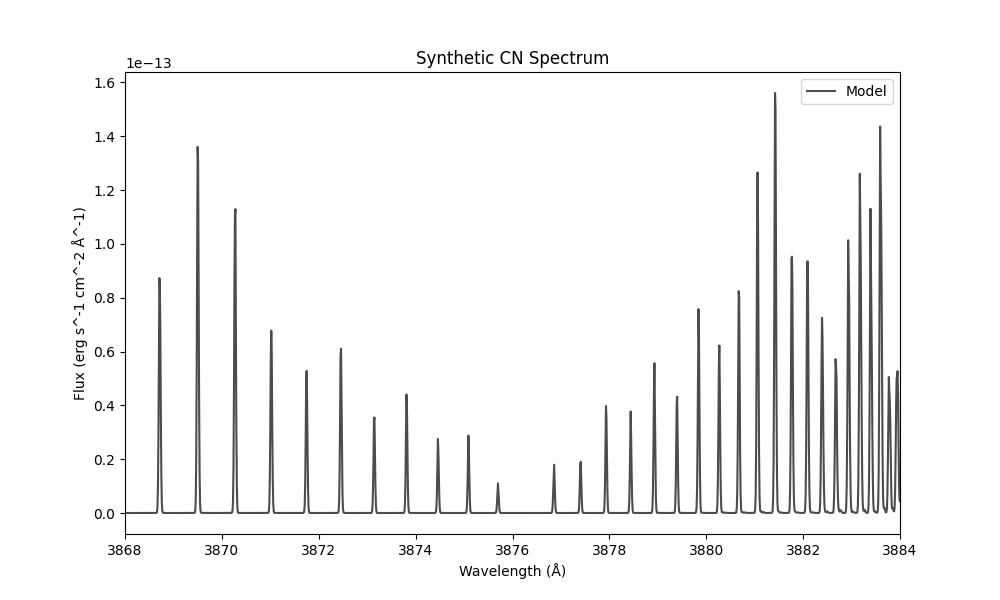

In [ ]:
# wave_col, flux_col, error_col, continuum_col can be changed to your data coluns names omega 
# is the solid angle in sr of the observation default is assuming circular of radius 0.5 arcsec
# default line list 12C14N including B-X 00 and A-X delta v=1 (violet and red systems)

model = FluorescenceModel(
    data=spectra,  #this is just used on the fitting stage but let's attach it here
    pumping=solar,  #solar pumping spectrum
    window = (3868.0, 3884.0), #wavelength range to be modeled and fitted
    lsf=None,  #no pre computed lsf function provided, None it will be set then other params
    lsf_method="Gauss_Lorentz",  #method to use to compute the lsf if no lsf function is provided
    A_min=1e4,  #minimum Einstein A coefficient to consider form the line list
    name=f'CN_Model {night}',  #name of the model
    sigma_G=0.015, #initial parameter for the Gaussian sigma
    fwhm_L=0.005, #initial parameter for the Lorentzian FWHM
    ratio = 0.95,  #initial parameter for the Gauss-Lorentz ratio
    logN=12,  #initial parameter for the column density log10 value
    v_kms=0.0,  #initial parameter for the velocity shift in km/s (in case small shifts are needed)
    T=300.0,  #initial parameter for the rotational temperature in K
    logQ=-2,  #initial parameter for the log10 of the collisions rate in s^-1),
)



plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum')
plt.legend()
plt.show()

When creating the model there are multiple useful atribute so check the doc

### I recommend to be concistent with the lsf_method choosen and the parameters given to the model, all the codes will read first lsf_method

Gauss_Lorentz uses sigma_G, sigma_L and ratio (between gauss and lorentz)
Gauss uses only sigma
2Gauss uses sigma_1, sigma_2 and ratio (between gauss and gauss2)

if one is choosen please do not provide parameters for the other lsf methods, or set them to None. It should work even if you provide all the parameters but its better to avoid confusion or bugs.

one can update parameters and re calculate the model easily, **update_model()** function
is needed after changing any parameter to update the model, parameters can be given also to update_model function directly, and that will overwrite the current ones
this step is needed as it also need to recalculate the model

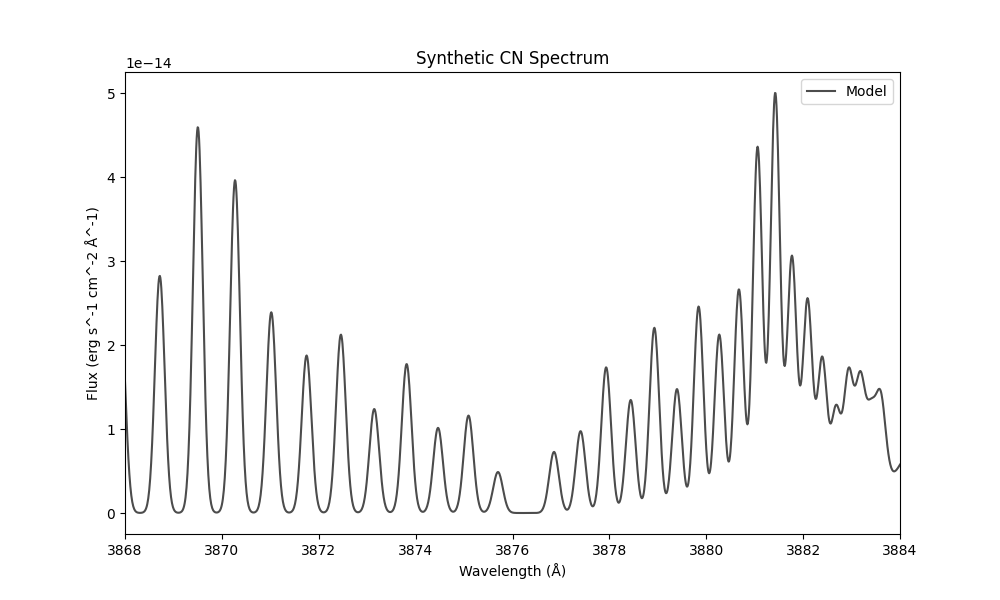

In [ ]:
model.lsf_method = 'Gauss'
model.sigma = 0.1
model.logQ = -1
model.update_model()

plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum')
plt.legend()
plt.show()

# Now lets do 2 types of fitting, one with lsf fixed and one with lsf free to vary

For the calculations of J_nu it is assumed a delta de dirac, no doppler broadening. it does not change significantly, if the physical line profile is narrow. It is not included for fitting as the matrix to be computed is not trivial so the computationtime will increase a lot if is calculated in each step of mcmc.

Pleae increase the nwalwers and steos, now is low just for testing purposes

In [ ]:
from pyfluor.fluorescence import FluorescenceModel

priors = {
    'logN': (5, 20),          # log10 column density [cm^-2]
    'logQ': (-5, -1),         # log10 collision rate [s^-1]
    'T': (10, 400),         # kinetic temperature [K]
}
#initialize a model with a fixed lsf
model = FluorescenceModel(
    data=spectra, 
    window = (3866.0, 3884.0), 
    pumping=solar, 
    lsf=None,  
    lsf_method="Gauss",  
    A_min=1e4, 
    name=f'CN_Model {night}', 
    sigma = 0.01,
    logN=12.0, 
    v_kms=0.0,  
    T=300.0, 
    logQ=-2.0,
    isotopologues=['12C14N'],
)

priors2 = {
     'logN': (5, 20),          # log10 column density [cm^-2]
     'logQ': (-8, 1),         # log10 collision rate [s^-1]
     'T': (10, 1000),         # kinetic temperature [K]
     'fwhm_L': (0.001, 0.03),    # LSF fwhm 1
     'v_kms': (-1.0, 1.0)
}

model2 = FluorescenceModel(
    data=spectra,  #this is just used on the fitting stage but let's attach it here
    window = (3866.0, 3886.0), #wavelength range to be modeled and fitted
    pumping=solar, 
    lsf=None,  #no pre computed lsf function provided it will be set then with paras
    lsf_method="Lorentz",  #method to use to compute the lsf if no lsf function is provided
    A_min=1e4,  #minimum Einstein A coefficient to consider form the line list
    name=f'CN_Model {night}',  #name of the model
    fwhm_L=0.005, #initial parameter for the Lorentzian FWHM
    logN=12.0,  #initial parameter for the column density log10 value
    v_kms=0.0,  #initial parameter for the velocity shift in km/s (in case small shifts are needed)
    T=300.0,  #initial parameter for the rotational temperature in K
    logQ=-2.0,  #initial parameter for the log10 of the collisions rate in s^-1)
)


Number of iterations: 6000


100%|██████████| 200/200 [00:56<00:00,  3.56it/s]


##################################################
*** Best fit (no pruning) ***
logN: 11.4976
logQ: -1.00089
T: 223.402
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.386
logN: 11.4974 +/- 0.0084  [11.4882, 11.5050]
logQ: -1.0203 +/- 0.0299  [-1.0641, -1.0043]
T: 217.9280 +/- 6.3096  [211.8837, 224.5029]


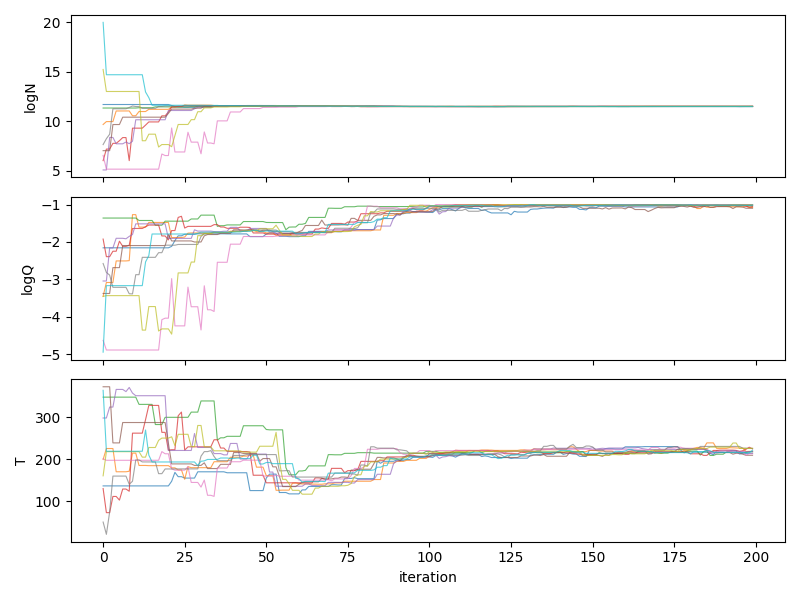

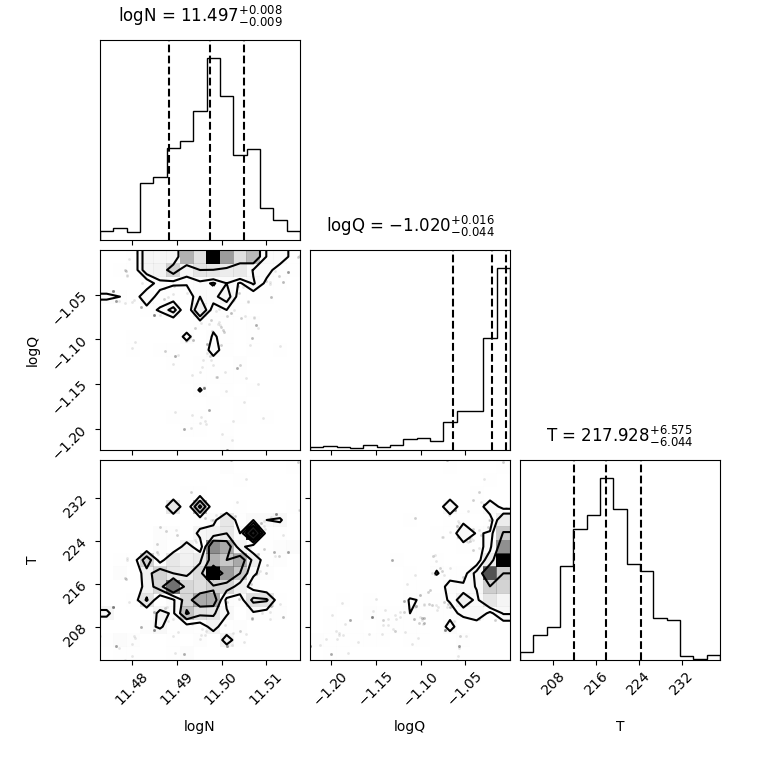

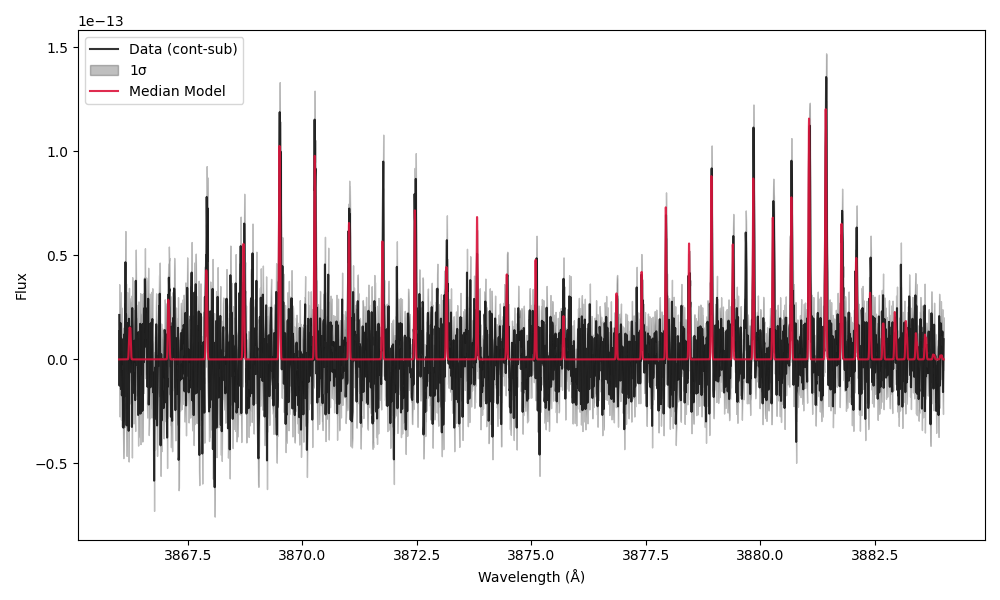

Number of iterations: 10000


100%|██████████| 200/200 [00:51<00:00,  3.91it/s]


##################################################
*** Best fit (no pruning) ***
logN: 11.6737
logQ: 0.047815
T: 236.159
fwhm_L: 0.0243249
v_kms: 0.581287
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.359
logN: 11.6737 +/- 0.0079  [11.6648, 11.6806]
logQ: -0.4299 +/- 0.2931  [-0.6587, -0.0724]
T: 235.0172 +/- 8.7394  [226.6361, 244.1149]
fwhm_L: 0.0236 +/- 0.0008  [0.0228, 0.0244]
v_kms: 0.5712 +/- 0.0319  [0.5505, 0.6142]


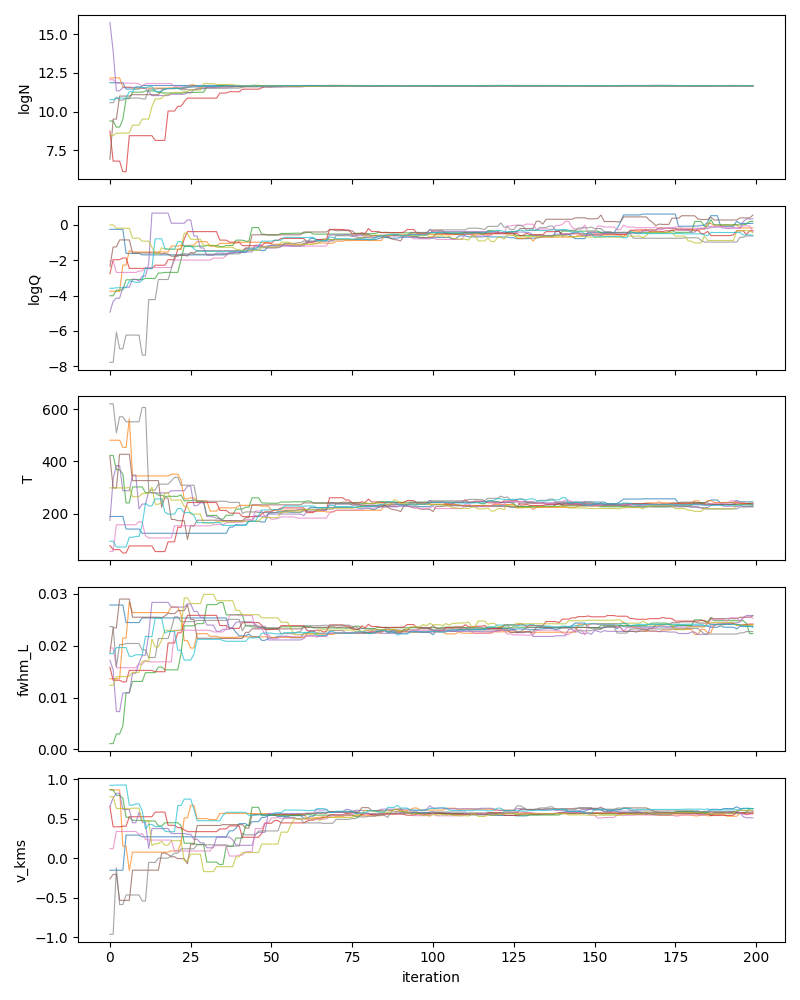

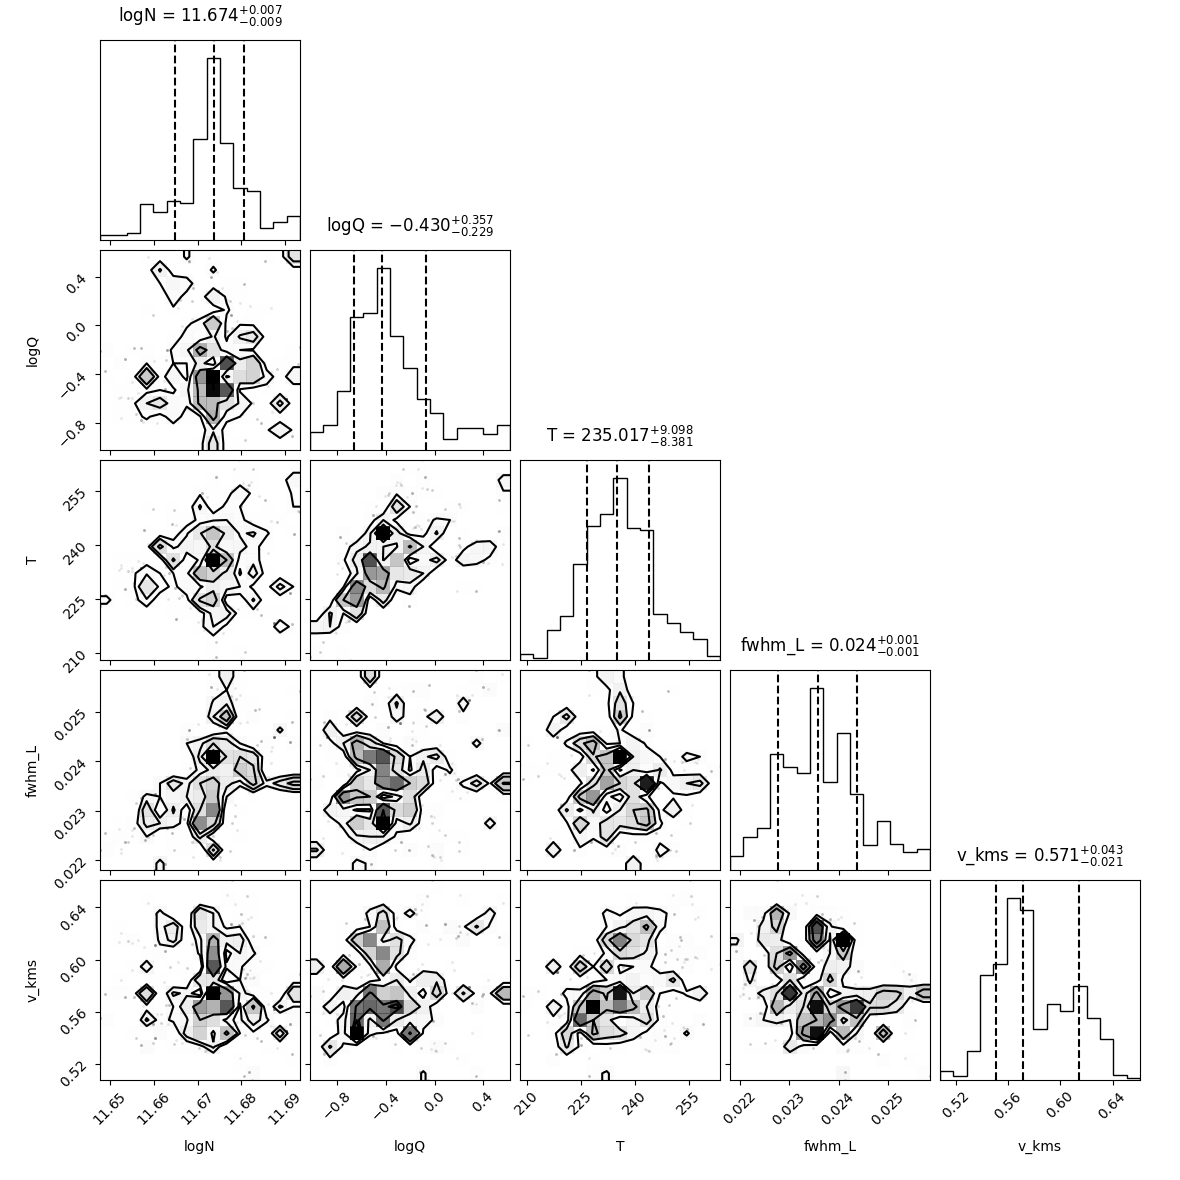

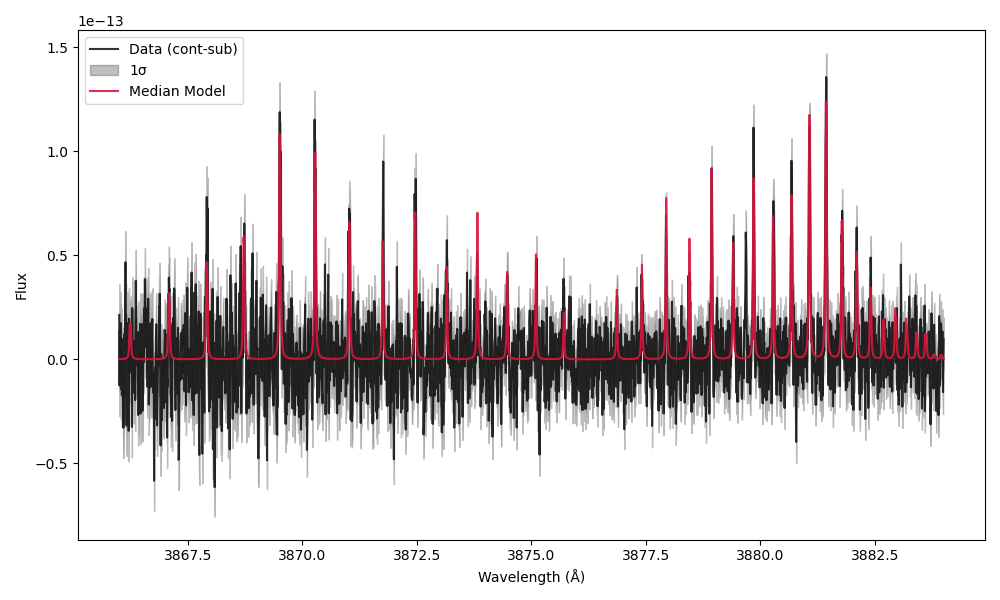

{'param_keys': ['logN', 'logQ', 'T', 'fwhm_L', 'v_kms'],
 'median_params': {'logN': 11.673730546782593,
  'logQ': -0.42986568675899717,
  'T': 235.01717907692142,
  'fwhm_L': 0.02358289183462749,
  'v_kms': 0.5712366512733872},
 'up_errors_params': {'logN': 0.006834256932675586,
  'logQ': 0.3574585401018751,
  'T': 9.097738702872192,
  'fwhm_L': 0.0007793568255122542,
  'v_kms': 0.04299405649275634},
 'low_errors_params': {'logN': 0.008901252390984382,
  'logQ': 0.22883683602069216,
  'T': 8.381118840492263,
  'fwhm_L': 0.0008087881981788912,
  'v_kms': 0.020718557483495714},
 'samples_pruned': array([[ 1.16523674e+01, -7.57964392e-01,  2.33686547e+02,
          2.21374270e-02,  5.84342731e-01],
        [ 1.16717504e+01, -5.35538241e-01,  2.36152837e+02,
          2.26969877e-02,  6.07676557e-01],
        [ 1.16840002e+01, -4.46050201e-01,  2.43997601e+02,
          2.34907740e-02,  5.64304326e-01],
        ...,
        [ 1.16740458e+01, -6.23392081e-01,  2.25849548e+02,
          2.27

In [ ]:
# include_rotations needs to set False to exclude rotational collisions

model.fit_mcmc(data = spectra,
               window=model.window,
               pumping=solar,
               nwalkers=10,
               nsteps=200,
               priors=priors,
               lsf=model.lsf,
               make_plots=True,
               progress=True,
               A_min=1e5,
               a=3,
               threads=4,
               fig_file='Example_plots/example1',
               include_rotations=True
               ) 

model2.fit_mcmc(data = spectra,
               window=model.window,
               pumping=solar,
               nwalkers=10,
               nsteps=200,
               priors=priors2,
               make_plots=True,
               progress=True,
               A_min=1e5,
               a=3,
               threads=4,
               fig_file=f'Example_plots/example2'
               )

look that there are good parameters from there:

self.param_keys
self.median_params
self.up_errors_params
self.low_errors_params

self.samples_pruned
self.lnprob_pruned 

self.model_wave
self.median_model
self.model_p16
self.model_p84 

# You can save the model and results as a pickle file for later use
# Example of loading the model again

The good thing of saving everything in a pickel is that if any corner plot or the histograms of the parameters or anything else is needed later, you can just load the model and have everything ready without needing to re run the MCMC fitting again. For the corner plots the samples_pruned atribute is very useful as is the chain of mcmc, so you can use corner package with that atribute.

In [ ]:
model.save(filename=f'MCMC_results/example1.pkl')

# And you can load the model again

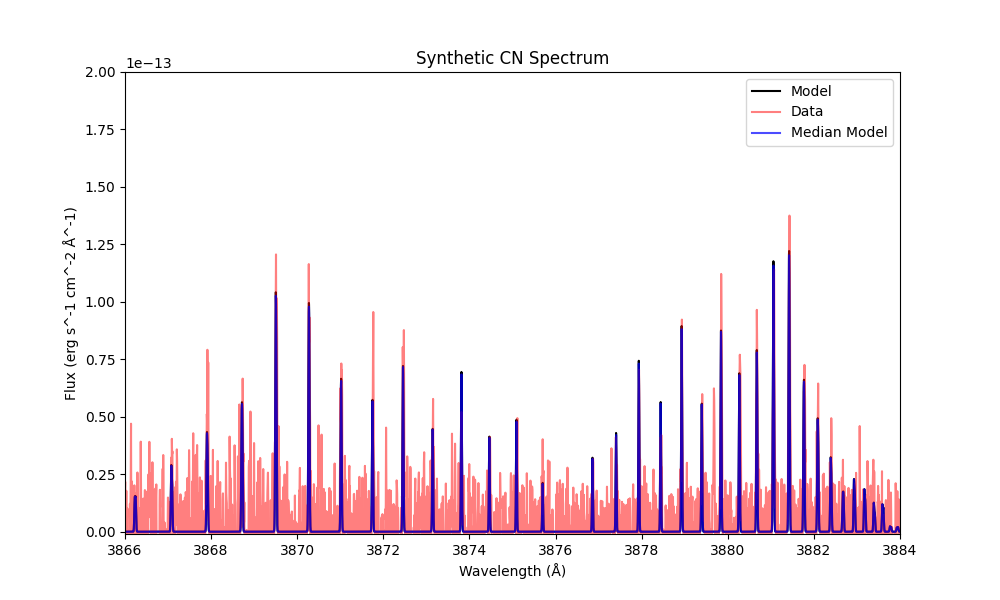

Best fit parameters:
logN: 11.4974 (+0.0076/-0.0092)
logQ: -1.0203 (+0.0160/-0.0438)
T: 217.9280 (+6.5749/-6.0443)


In [4]:
%matplotlib widget
from pyfluor.fluorescence import FluorescenceModel
from matplotlib import pyplot as plt

model = FluorescenceModel.load(filename=f'MCMC_results/example1.pkl')

plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=1, label='Model')
plt.plot(model.data['WAVE'], model.data['FLUX_STACK'], color='r', alpha=0.5, label='Data')
plt.plot(model.model_wave, model.median_model, color='b', alpha=0.7, label='Median Model')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.ylim(-1e-15, 2e-13)
plt.title('Synthetic CN Spectrum')
plt.legend()
plt.show()

#print best fit parameters and errors
print("Best fit parameters:")
for key in model.param_keys:
    median = model.median_params[key]
    lower = model.low_errors_params[key]
    upper = model.up_errors_params[key]
    print(f"{key}: {median:.4f} (+{upper:.4f}/-{lower:.4f})")

# Now lets compute the production rates

you need distance to the comets (delta) and aperture type and shape daughter_length_km: float,
v_outflow_km_s: float,

In [ ]:
import numpy as np

#Now lets compute 
delta_au = mean_values['mean_delta_au']
parent_length_km = (1.3e4 * mean_values['mean_r_au']**2) 
daughter_length_km = (2.1e5 * mean_values['mean_r_au']**2)
v_outflow = (0.85 / np.sqrt(mean_values['mean_r_au']))
aperture = {'type': 'circular', 'radius_arcsec': 0.5}
# aperture = {"type":"rectangular","width_arcsec":X,"length_arcsec":Y}
result = model.compute_production_rate(delta_au=delta_au, parent_length_km=parent_length_km, 
                              daughter_length_km=daughter_length_km, v_outflow_km_s=v_outflow,
                              aperture=aperture, use_samples=True )

#you can acces by:
print(result)
#or
print(model.q, model.q_err)

(26.01372413798317, 0.008422428843413599)
26.01372413798317 0.008422428843413599


that error is just the mcmc statistical error, one important systematics is the slit loss, lets add it: for this we will need the minimum and maximum seeing (at 500 nm and at the zenith) during the observations and the minimum and maximum angle from the zenith during the observations. And the wavelength in which will be stimated the slit loss so for the CN band its 3880 AA

In [ ]:
print('old:', model.q, '+-', model.q_err)
new_error = model.add_slit_loss_error(lambda_nm=388.0,
                                        eps_min_arcsec_500=0.8,
                                        eps_max_arcsec_500=1.2,
                                        zmin_deg=20,
                                        zmax_deg=40,
                                        aperture=aperture)

#now the model should have updated its error:
print('new:', model.q, '+-', model.q_err)

old: 26.01372413798317 +- 0.008422428843413599
new: 26.01372413798317 +- 0.171737775465038


In [ ]:
# if you try it again is not going to change anything
new_error = model.add_slit_loss_error(lambda_nm=388.0,
                                        eps_min_arcsec_500=0.8,
                                        eps_max_arcsec_500=1.2,
                                        zmin_deg=20,
                                        zmax_deg=40,
                                        aperture=aperture)
print('new:', model.q, '+-', model.q_err)

It was already corrected, there is no need to apply it again.
new: 26.01372413798317 +- 0.171737775465038


### With that we have already done everything, however we are going to do some examples of different scenarios, multiple isotopes, your own lists, different molecule systems.

1) More than one isotope plus filtering to just the B-X sistem plus your own lsf

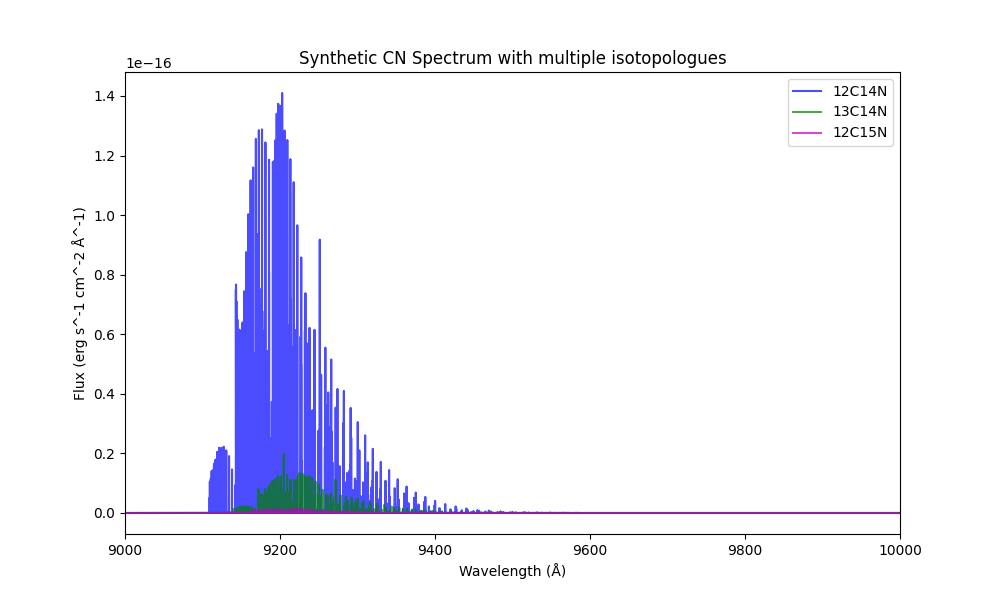

In [7]:
def lsf(x):
    """Example of a custom LSF function: a simple Gaussian."""
    sigma = 0.02  # Standard deviation of the Gaussian
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x) / sigma) ** 2)

model = FluorescenceModel(pumping=solar,
                          isotopologues=['12C14N', '13C14N', '12C15N'],
                          systems=['A-X'],
                          lsf=lsf,
                          A_min=1e3,
                          logN_by_iso={'12C14N': 10, '13C14N': 9, '12C15N': 8},
                          logQ= -2,
                          T=300.0,
                          window=(9000.0, 10000.0),)


# lets add noise to the model to create data

continuum = np.array([0 for _ in model.model_wave])
noise_level = 1e-20
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0, noise_level, size=model.model_wave.shape)
flux_with_noise = model.best_model + noise
data_with_noise = pd.DataFrame({'WAVE': model.model_wave, 'FLUX_STACK': flux_with_noise, 'ERR_STACK': noise_level, 'CONTINUUM': continuum})
# This is how you acces each isotopologue model separately

plt.figure(figsize=(10, 6))
# plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model')
plt.plot(model.model_by_iso['12C14N'][0], model.model_by_iso['12C14N'][1], color='b', alpha=0.7, label='12C14N')
plt.plot(model.model_by_iso['13C14N'][0], model.model_by_iso['13C14N'][1], color='g', alpha=0.7, label='13C14N')
plt.plot(model.model_by_iso['12C15N'][0], model.model_by_iso['12C15N'][1], color='m', alpha=0.7, label='12C15N')
# plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum with multiple isotopologues')
plt.legend()
plt.show()


# priors = {
#     'logN_12C14N': (9, 11),
#     'logN_13C14N': (8, 10),
#     'logN_12C15N': (7, 9),
#     'logQ': (-5, -1),
#     'T': (10, 400),
# }

# model.fit_mcmc(data=data_with_noise,
#                window=model.window,
#                pumping=solar,
#                nwalkers=10,
#                nsteps=200,
#                priors=priors,
#                make_plots=False,
#                isotopologues=['12C14N', '13C14N', '12C15N'],
#                systems=['B-X'],
#                lsf=lsf,
#                A_min=1e-4,
#                a=3,
#                threads=4,
#                progress=True)


In [32]:
print(model.lines_by_iso['12C14N'])

   lambda_vac_A      A_ul          upper_id       ... __upper_idx __lower_idx
                                                  ...                        
------------------ -------- --------------------- ... ----------- -----------
 9199.051890517852 8931.573  A|v=1|J=1.5|sym=F1_e ...           0           1
  9201.72166052613 13389.02  A|v=1|J=2.5|sym=F1_e ...           2           3
 9204.816434927283 16324.94  A|v=1|J=3.5|sym=F1_e ...           4           5
 9208.334102229232 18537.92  A|v=1|J=4.5|sym=F1_e ...           6           7
 9212.271895856813 20331.21  A|v=1|J=5.5|sym=F1_e ...           8           9
 9216.626898150485 21844.39  A|v=1|J=6.5|sym=F1_e ...          10          11
 9221.395611196638  23150.9  A|v=1|J=7.5|sym=F1_e ...          12          13
 9226.574801475019 24293.74  A|v=1|J=8.5|sym=F1_e ...          14          15
 9232.161156605149 25300.59  A|v=1|J=9.5|sym=F1_e ...          16          17
               ...      ...                   ... ...         ..

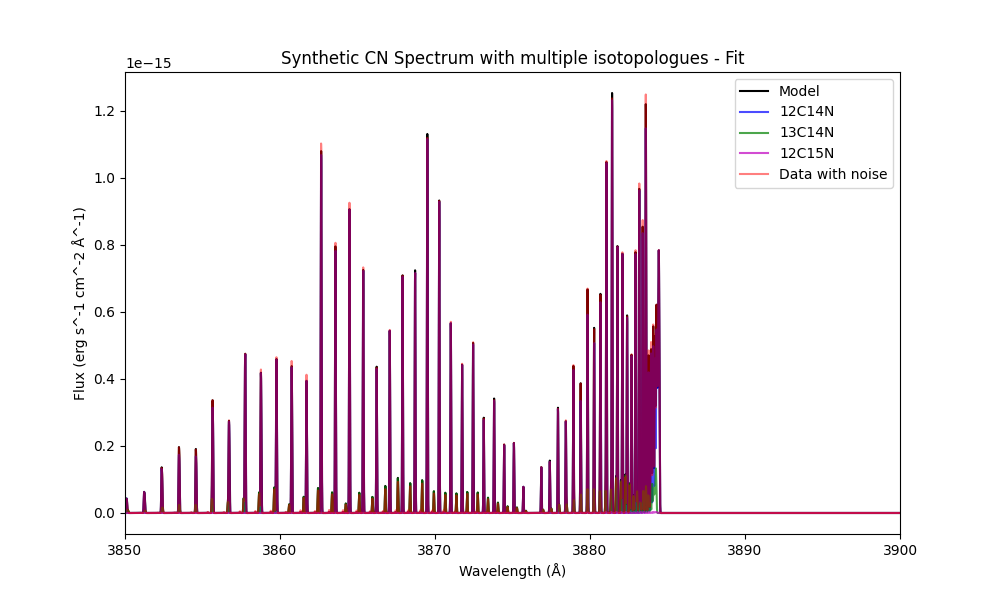

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=1, label='Model')
plt.plot(model.model_by_iso['12C14N'][0], model.model_by_iso['12C14N'][1], color='b', alpha=0.7, label='12C14N')
plt.plot(model.model_by_iso['13C14N'][0], model.model_by_iso['13C14N'][1], color='g', alpha=0.7, label='13C14N')
plt.plot(model.model_by_iso['12C15N'][0], model.model_by_iso['12C15N'][1], color='m', alpha=0.7, label='12C15N')
plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum with multiple isotopologues - Fit')
plt.legend()
plt.show()

#Now lets compute 
delta_au = mean_values['mean_delta_au']
parent_length_km = (1.3e4 * mean_values['mean_r_au']**2) 
daughter_length_km = (2.1e5 * mean_values['mean_r_au']**2)
v_outflow = (0.85 / np.sqrt(mean_values['mean_r_au']))
aperture = {'type': 'circular', 'radius_arcsec': 0.5}
# aperture = {"type":"rectangular","width_arcsec":X,"length_arcsec":Y}
result = model.compute_production_rate(delta_au=delta_au, parent_length_km=parent_length_km, 
                              daughter_length_km=daughter_length_km, v_outflow_km_s=v_outflow,
                              aperture=aperture, use_samples=True )

In [ ]:
print(result)
model.add_slit_loss_error(lambda_nm=388.0,
                                        eps_min_arcsec_500=0.8,
                                        eps_max_arcsec_500=1.2,
                                        zmin_deg=20,
                                        zmax_deg=40,
                                        aperture=aperture)
print(model.q, model.q_err)


{'12C14N': (24.508133387499285, 0.0009427636418646301), '13C14N': (23.556672808056135, 0.012043369507587443), '12C15N': (22.08422212709719, 0.007078161886637346)}
{'12C14N': 24.508133387499285, '13C14N': 23.556672808056135, '12C15N': 22.08422212709719} {'12C14N': 0.1715337139379366, '13C14N': 0.1719533918338156, '12C15N': 0.1716770997825595}


2) Atomic lines provided by the user

In [ ]:
lines_wave = [3800, 3810, 3820, 3830, 3840] #wavelengths in Angstroms
A = [1e4, 1e4, 1e4, 1e4, 1e4] #einstein A coefficients
upper_id_col = ['2', '3', '4', '5', '6']
lower_id_col = ['1', '1', '1', '1', '1'] # this are the unique ids fpr the upper and lower states, for instance in this case the unique line will
# 31, 21, 11
g_upper_col = [1, 1, 1, 1, 1] # statistical weights of the upper levels
g_lower_col = [1, 1, 1, 1, 1] # statistical weights of the lower levels

#with this we create a line list as a pandas DataFrame
custom_linelist = pd.DataFrame({'WAVE': lines_wave,
                               'A_EINSTEIN': A,
                               'UPPER_ID': upper_id_col,
                               'LOWER_ID': lower_id_col,
                               'G_UPPER': g_upper_col,
                               'G_LOWER': g_lower_col
                               })

# now it need to be transformed in the allowed format this is by using the following function

from pyfluor.modeling import from_user_linelist

lines_custom = from_user_linelist(custom_linelist,
                                lam_col =  'WAVE',
                                A_col = 'A_EINSTEIN',
                                upper_id_col = 'UPPER_ID',
                                lower_id_col = 'LOWER_ID',
                                g_upper_col = 'G_UPPER',
                                g_lower_col = 'G_LOWER')

In [ ]:
lines_custom

,lambda_vac_A,A_ul,upper_id,lower_id,g_upper,g_lower,E_cm1
0,3800.0,10000.0,2,1,1.0,1.0,26315.789474
1,3810.0,10000.0,3,1,1.0,1.0,26246.719160
2,3820.0,10000.0,4,1,1.0,1.0,26178.010471
3,3830.0,10000.0,5,1,1.0,1.0,26109.660574
4,3840.0,10000.0,6,1,1.0,1.0,26041.666667


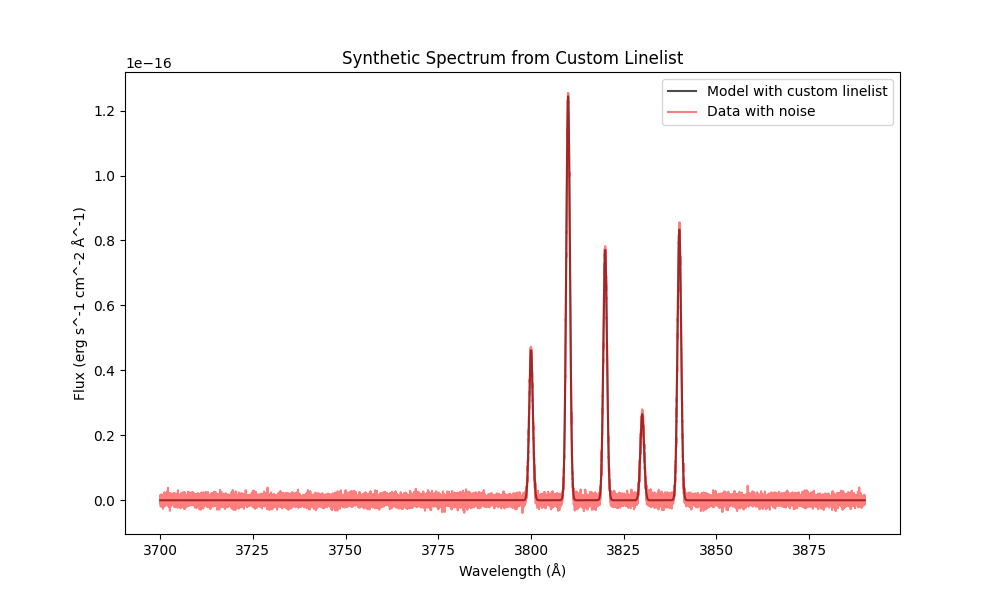

Number of iterations: 4000


100%|██████████| 200/200 [00:03<00:00, 61.10it/s]


##################################################
*** Best fit (no pruning) ***
logN: 11.9998
sigma: 0.499498
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.44499999999999995
logN: 11.9997 +/- 0.0003  [11.9995, 12.0000]
sigma: 0.4994 +/- 0.0004  [0.4990, 0.4999]


{'param_keys': ['logN', 'sigma'],
 'median_params': {'logN': 11.999738772129282, 'sigma': 0.4993728980158598},
 'up_errors_params': {'logN': 0.0002855908730126089,
  'sigma': 0.0005147000947807734},
 'low_errors_params': {'logN': 0.0002680698683494853,
  'sigma': 0.0003603538512771953},
 'samples_pruned': array([[11.99937987,  0.49843151],
        [11.99968539,  0.4996817 ],
        [11.99971513,  0.49860209],
        ...,
        [11.99998377,  0.49980708],
        [11.99963509,  0.49921634],
        [11.99973333,  0.49975719]], shape=(994, 2)),
 'lnprob_pruned': array([760482.31630632, 760485.0048931 , 760482.51681232, 760484.39057077,
        760482.66063484, 760480.77192239, 760484.41397289, 760484.0810737 ,
        760484.89831807, 760485.34960557, 760484.0733025 , 760485.13425108,
        760482.51681232, 760484.39057077, 760482.66063484, 760480.63000264,
        760484.41397289, 760484.0810737 , 760484.48892417, 760485.34960557,
        760484.0733025 , 760485.13425108, 760482.5

In [ ]:
# now we create the model using the custom line list
model = FluorescenceModel(
    pumping=solar,
    isotopologues=['Fe'],
    window=(3700.0, 3890.0),
    linelists=lines_custom,
    lsf=None,
    lsf_method="Gauss",
    sigma=0.5,
    A_min=1e3,
    logN=12,
    include_rotations=False #this is important to set False when using custom linelists without rotational collision data eg atomic lines
)
plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model with custom linelist')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic Spectrum from Custom Linelist')


# lets add noise

continuum = np.array([0 for _ in model.model_wave])
noise_level = 1e-18
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0, noise_level, size=model.model_wave.shape)
flux_with_noise = model.best_model + noise
data_with_noise = pd.DataFrame({'WAVE': model.model_wave, 'FLUX_STACK': flux_with_noise, 'ERR_STACK': noise_level, 'CONTINUUM': continuum})

plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.legend()
plt.show()

priors = {
    'logN': (5, 20),          # log10 column density [cm^-2]
    'sigma': (0.1, 1)
}
model.fit_mcmc(data=data_with_noise,
               window=model.window,
               pumping=solar,
               nwalkers=10,
               nsteps=200,
               priors=priors,
               make_plots=False,
               progress=True,
               A_min=1e3,
               a=3,
               threads=4,
               )

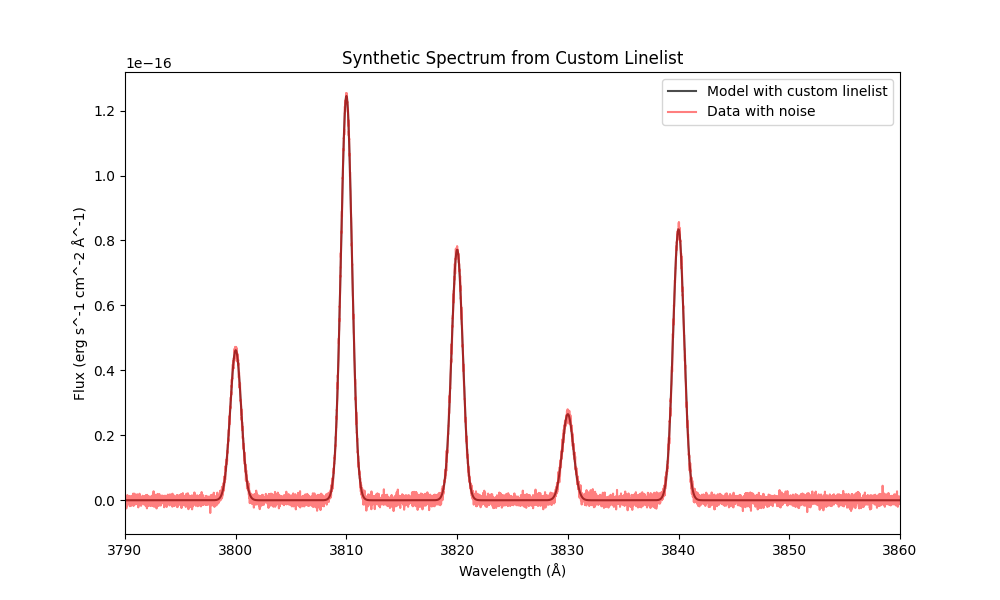

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model with custom linelist')
plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.xlabel('Wavelength (Å)')
plt.xlim(3790, 3860)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic Spectrum from Custom Linelist')
plt.legend()
plt.show()

In [ ]:
#this are random values just to test the production rate computation
delta_au = mean_values['mean_delta_au']
parent_length_km = (1.3e4 * mean_values['mean_r_au']**2) 
daughter_length_km = (2.1e5 * mean_values['mean_r_au']**2)
v_outflow = (0.85 / np.sqrt(mean_values['mean_r_au']))
aperture = {'type': 'circular', 'radius_arcsec': 0.5}
# aperture = {"type":"rectangular","width_arcsec":X,"length_arcsec":Y}
result = model.compute_production_rate(delta_au=delta_au, parent_length_km=parent_length_km, 
                              daughter_length_km=daughter_length_km, v_outflow_km_s=v_outflow,
                              aperture=aperture, use_samples=True )
print(result)
model.add_slit_loss_error(lambda_nm=388.0,
                                        eps_min_arcsec_500=0.8,
                                        eps_max_arcsec_500=1.2,
                                        zmin_deg=20,
                                        zmax_deg=40,
                                        aperture=aperture)
print(model.q, model.q_err)


(26.516075187211257, 0.0002768303706819353)
It was already corrected, there is no need to apply it again.
26.516075187211257 0.0002768303706819353


3) Two iso provided by the user including rotational collisions

In [ ]:
lines_wave = [3800, 3810, 3820, 3830, 3840] #wavelengths in Angstroms
A = [1e4, 1e4, 1e4, 1e4, 1e4] #einstein A coefficients
upper_id_col = ['2', '3', '4', '5', '6']
lower_id_col = ['1', '1', '1', '1', '1'] # this are the unique ids fpr the upper and lower states, for instance in this case the unique line will
# 31, 21, 11
g_upper_col = [1, 1, 1, 1, 1] # statistical weights of the upper levels
g_lower_col = [1, 1, 1, 1, 1] # statistical weights of the lower levels

loweres = ['X', 'X', 'X', 'X', 'X'] #lower electronic state
lowerv = [0, 0, 0, 0, 0] #lower vibrational state
lowerJ = [1.5, 2.5, 3.5, 4.5, 6.5] # Lower state J level
lowersym = ['F1e', 'F1e', 'F1e', 'F1e', 'F1e'] # Lower state symmetry Lower state F level plus Lower state parity
Elower = [11, 12, 13, 14, 15] # Lower state energy in cm^-1

#the format needed comes from pgopher, however it will may (not sure), work with other formats in the lists

#with this we create a line list as a pandas DataFrame
custom_linelist_1 = pd.DataFrame({'WAVE': lines_wave,
                               'A_EINSTEIN': A,
                               'UPPER_ID': upper_id_col,
                               'LOWER_ID': lower_id_col,
                               'G_UPPER': g_upper_col,
                               'G_LOWER': g_lower_col,
                               'LOWER_ELECTRONIC_STATE': loweres,
                               'LOWER_VIBRATIONAL_STATE': lowerv,
                               'LOWER_J_LEVEL': lowerJ,
                               'LOWER_SYMMETRY': lowersym,
                               'E_LOWER': Elower
                               })

# now it need to be transformed in the allowed format this is by using the following function

from pyfluor.modeling import from_user_linelist

lines_custom_1 = from_user_linelist(custom_linelist_1,
                                lam_col =  'WAVE',
                                A_col = 'A_EINSTEIN',
                                upper_id_col = 'UPPER_ID',
                                lower_id_col = 'LOWER_ID',
                                g_upper_col = 'G_UPPER',
                                g_lower_col = 'G_LOWER',
                                lower_es_col = 'LOWER_ELECTRONIC_STATE',
                                lower_v_col = 'LOWER_VIBRATIONAL_STATE',
                                lower_J_col = 'LOWER_J_LEVEL',
                                lower_sym_col = 'LOWER_SYMMETRY',
                                E_lower_cm1_col = 'E_LOWER',)

custom_linelist_2 = custom_linelist_1.copy()
custom_linelist_2['WAVE'] = custom_linelist_2['WAVE'] + 5.0

# now it need to be transformed in the allowed format this is by using the following function


lines_custom_2 = from_user_linelist(custom_linelist_2,
                                lam_col =  'WAVE',
                                A_col = 'A_EINSTEIN',
                                upper_id_col = 'UPPER_ID',
                                lower_id_col = 'LOWER_ID',
                                g_upper_col = 'G_UPPER',
                                g_lower_col = 'G_LOWER',
                                lower_es_col = 'LOWER_ELECTRONIC_STATE',
                                lower_v_col = 'LOWER_VIBRATIONAL_STATE',
                                lower_J_col = 'LOWER_J_LEVEL',
                                lower_sym_col = 'LOWER_SYMMETRY',
                                E_lower_cm1_col = 'E_LOWER',)

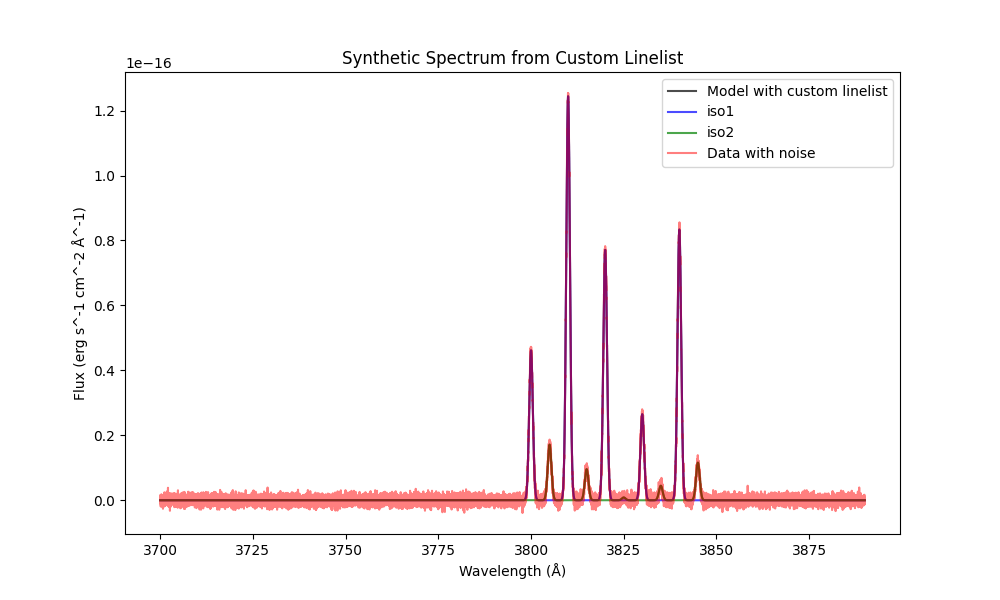

Number of iterations: 10000


100%|██████████| 200/200 [00:05<00:00, 35.12it/s]


##################################################
*** Best fit (no pruning) ***
logN_iso1: 12.0134
logN_iso2: 10.8694
sigma: 0.511852
logQ: -3.89885
T: 13.9689
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.3375
logN_iso1: 12.0144 +/- 0.0011  [12.0133, 12.0155]
logN_iso2: 10.8732 +/- 0.0058  [10.8678, 10.8793]
sigma: 0.5186 +/- 0.0017  [0.5161, 0.5195]
logQ: -3.7776 +/- 0.0475  [-3.8389, -3.7438]
T: 240.3844 +/- 150.8458  [71.3835, 373.0751]


{'param_keys': ['logN_iso1', 'logN_iso2', 'sigma', 'logQ', 'T'],
 'median_params': {'logN_iso1': 12.014447709403617,
  'logN_iso2': 10.87315953515928,
  'sigma': 0.5186167292915342,
  'logQ': -3.7775837241078487,
  'T': 240.38441468035077},
 'up_errors_params': {'logN_iso1': 0.001035244963150106,
  'logN_iso2': 0.0061547432006641145,
  'sigma': 0.0008623541985993688,
  'logQ': 0.03376280307919899,
  'T': 132.6906422470125},
 'low_errors_params': {'logN_iso1': 0.0011699775961933057,
  'logN_iso2': 0.00535069851347636,
  'sigma': 0.002500711681669099,
  'logQ': 0.06127813842090335,
  'T': 169.00096142316278},
 'samples_pruned': array([[ 12.0131647 ,  10.86098259,   0.5184689 ,  -3.75156112,
         391.93139539],
        [ 12.01484048,  10.87625204,   0.52089416,  -3.72823533,
         392.41374239],
        [ 12.01284955,  10.86633759,   0.52042751,  -3.74265904,
         381.8974258 ],
        ...,
        [ 12.0139958 ,  10.87407611,   0.51534238,  -3.84964575,
          51.81336816]

In [ ]:
# now we create the model using the custom line list
model = FluorescenceModel(
    pumping=solar,
    isotopologues=['iso1', 'iso2'],
    window=(3700.0, 3890.0),
    linelists={'iso1': lines_custom_1, 'iso2': lines_custom_2},
    lsf=None,
    lsf_method="Gauss",
    sigma=0.5,
    A_min=1e3,
    logN_by_iso={'iso1': 12, 'iso2': 11},
    logQ= -2,
    T=300.0,
    include_rotations=True #this is important to set False when using custom linelists without rotational collision data eg atomic lines
)
plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model with custom linelist')
plt.plot(model.model_by_iso['iso1'][0], model.model_by_iso['iso1'][1], color='b', alpha=0.7, label='iso1')
plt.plot(model.model_by_iso['iso2'][0], model.model_by_iso['iso2'][1], color='g', alpha=0.7, label='iso2')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic Spectrum from Custom Linelist')


# lets add noise

continuum = np.array([0 for _ in model.model_wave])
noise_level = 1e-18
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0, noise_level, size=model.model_wave.shape)
flux_with_noise = model.best_model + noise
data_with_noise = pd.DataFrame({'WAVE': model.model_wave, 'FLUX_STACK': flux_with_noise, 'ERR_STACK': noise_level, 'CONTINUUM': continuum})

plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.legend()
plt.show()

priors = {
    'logN_iso1': (11, 13),          # log10 column density [cm^-2]
    'logN_iso2': (10, 12),          # log10 column density [cm^-2]
    'sigma': (0.1, 1),
    'logQ': (-5, -1),
    'T': (10, 400),
}
model.fit_mcmc(data=data_with_noise,
               window=model.window,
               pumping=solar,
               nwalkers=10,
               nsteps=200,
               priors=priors,
               make_plots=False,
               progress=True,
               A_min=1e3,
               a=3,
               threads=4,
               )

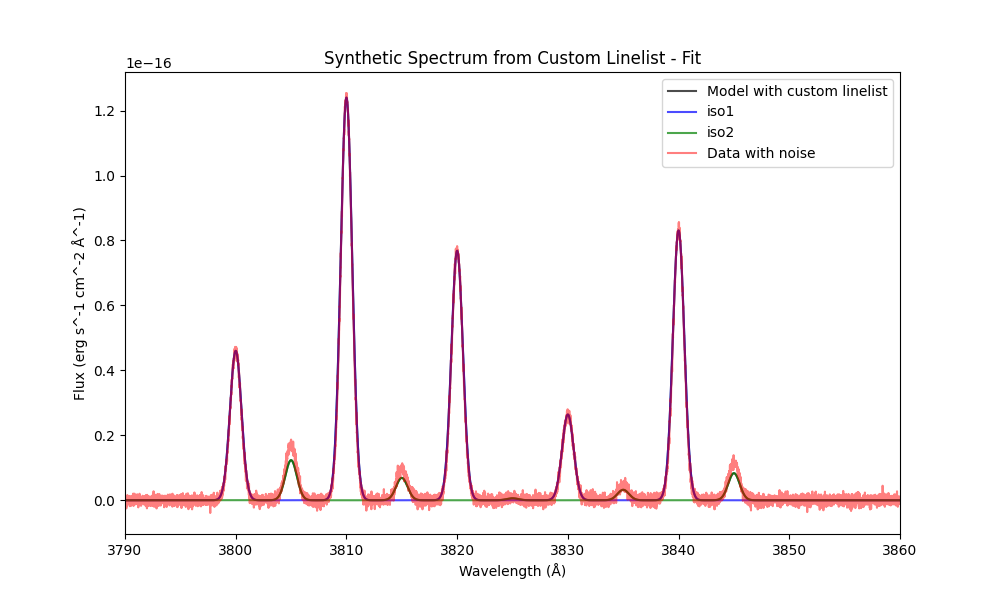

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model with custom linelist')
plt.plot(model.model_by_iso['iso1'][0], model.model_by_iso['iso1'][1], color='b', alpha=0.7, label='iso1')
plt.plot(model.model_by_iso['iso2'][0], model.model_by_iso['iso2'][1], color='g', alpha=0.7, label='iso2')
plt.plot(data_with_noise['WAVE'], data_with_noise['FLUX_STACK'], color='r', alpha=0.5, label='Data with noise')
plt.xlabel('Wavelength (Å)')
plt.xlim(3790, 3860)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic Spectrum from Custom Linelist - Fit')
plt.legend()
plt.show()